In [1]:
#import libraries
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv("C:/Users/gowth/DataSet/data_set_19/data/cleaned_bmw_sales_data.csv")
df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,...,Date,Quarter,Revenue_per_unit,Sales_Lag_1,Sales_Lag_3,Sales_Lag_6,Sales_Rolling_3,Sales_Rolling_6,Sales_Growth,EV_Demand_Index
0,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.50,...,2018-01-01,1,92300.0,7420.0,10280.0,7822.0,6333.000000,6309.666667,0.142049,0.03500
1,2018,1,China,X3,10727,57363,615332901,0.014,17.60,2.37,...,2018-01-01,1,57363.0,8474.0,3105.0,2554.0,8873.666667,7671.833333,0.265872,0.01428
2,2018,1,Europe,i4,10607,64082,679717774,0.035,19.12,3.50,...,2018-01-01,1,64082.0,10727.0,7420.0,6025.0,9936.000000,8435.500000,-0.011187,0.03500
3,2018,1,China,X5,8298,68390,567500220,0.017,17.60,2.37,...,2018-01-01,1,68390.0,10607.0,8474.0,10280.0,9877.333333,8105.166667,-0.217686,0.01734
4,2018,1,China,X7,9119,90034,821020046,0.020,17.60,2.37,...,2018-01-01,1,90034.0,8298.0,10727.0,3105.0,9341.333333,9107.500000,0.098940,0.02040


In [6]:
#Target data

target = "Units_Sold"
X = df.drop(columns=[target])
y = df[target]

In [ ]:
#Features

categorical_features = ["Region", "Model"]

numeric_features = [
    "Avg_Price_EUR",
    "BEV_Share",
    "Premium_Share",
    "GDP_Growth",
    "Fuel_Price_Index",
    "Sales_Lag_1",
    "Sales_Lag_3",
    "Sales_Rolling_3"
]

In [11]:
#feature transformation
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)


In [12]:
#Train , Test split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
#Ml pipeline

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

In [14]:
#Train Model
model.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [15]:
#prdict on test set
y_pred = model.predict(X_test)

In [16]:
#evalution metrics

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 1886.5093241042348
MSE: 5354333.181132452
RMSE: 2313.943210438072
R2: 0.4709264874860959


In [17]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Units_Sold', 'Avg_Price_EUR',
       'Revenue_EUR', 'BEV_Share', 'Premium_Share', 'GDP_Growth',
       'Fuel_Price_Index', 'Calculated_Revenue', 'Date', 'Quarter',
       'Revenue_per_unit', 'Sales_Lag_1', 'Sales_Lag_3', 'Sales_Lag_6',
       'Sales_Rolling_3', 'Sales_Rolling_6', 'Sales_Growth',
       'EV_Demand_Index'],
      dtype='object')

In [35]:
import warnings
warnings.filterwarnings('ignore')

Best iteration: 299
Test MAE : 496.02
Test RMSE: 681.60
Test R²  : 0.9611


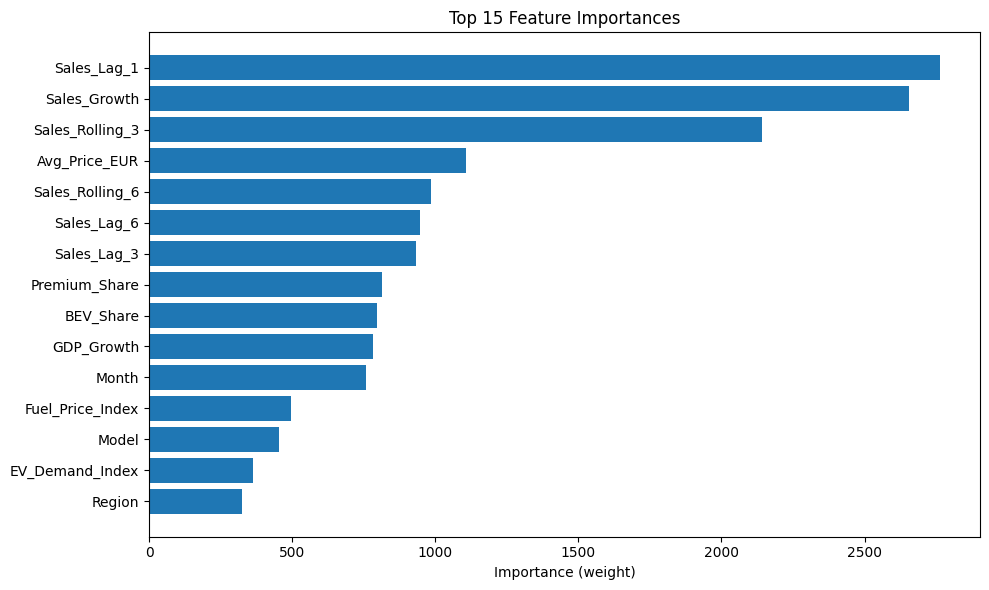

In [ ]:
#Model training with Selected features and Time-based split using xgboost

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

df = df.sort_values('Date').reset_index(drop=True)

exclude_cols = ['Revenue_EUR', 'Calculated_Revenue', 'Revenue_per_unit',
                'Date', 'Year', 'index']
feature_cols = [col for col in df.columns if col not in exclude_cols + ['Units_Sold']]

X = df[feature_cols].copy()
y = df['Units_Sold'].copy()

# Encode categoricals
categorical_cols = ['Region', 'Model']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Time‑based split
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Scale (optional, but harmless)
scaler = StandardScaler()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# ------------------------------------------------------------
# 2. Train using native XGBoost API with early stopping
# ------------------------------------------------------------
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test,  label=y_test)

params = {
    'objective': 'reg:squarederror',
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42
}

evals = [(dtrain, 'train'), (dtest, 'eval')]
model = xgb.train(
    params,
    dtrain,
    num_boost_round=300,
    evals=evals,
    early_stopping_rounds=20,
    verbose_eval=False          # set to True to see progress
)

# Best iteration
print(f"Best iteration: {model.best_iteration}")

# Predict
y_pred = model.predict(dtest)

# ------------------------------------------------------------
# 3. Evaluate
# ------------------------------------------------------------
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Test MAE : {mae:.2f}")
print(f"Test RMSE: {rmse:.2f}")
print(f"Test R²  : {r2:.4f}")

# ------------------------------------------------------------
# 4. Feature importance (from native model)
# ------------------------------------------------------------
importance_dict = model.get_score(importance_type='weight')  # or 'gain'
# Convert to DataFrame for plotting
importance = pd.DataFrame({
    'feature': list(importance_dict.keys()),
    'importance': list(importance_dict.values())
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance['feature'][:15], importance['importance'][:15])
plt.xlabel('Importance (weight)')
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Aggregated monthly data shape: (96, 7)
        Date  Units_Sold  Avg_Price_EUR  BEV_Share  Premium_Share  GDP_Growth  \
0 2018-01-01      192989   66096.961538   0.015769      15.181538    2.580385   
1 2018-02-01      201033   63867.093750   0.023563      14.682500    3.340000   
2 2018-03-01      250912   63707.687500   0.021063      14.570000    2.780000   
3 2018-04-01      249552   63876.437500   0.019813      12.577500    3.172500   
4 2018-05-01      218362   63916.312500   0.021687      14.772500    3.605000   

   Fuel_Price_Index  
0          0.986923  
1          1.007500  
2          0.992500  
3          1.007500  
4          1.005000  
Feature-engineered monthly data shape: (90, 16)

Test MAE : 13100.56
Test RMSE: 18032.62

12‑Month Sales Forecast:
         Date  Forecasted_Units_Sold
0  2026-01-01          267289.781250
1  2026-02-01          259484.296875
2  2026-03-01          277514.968750
3  2026-04-01          261185.968750
4  2026-05-01          261597.953125
5  20

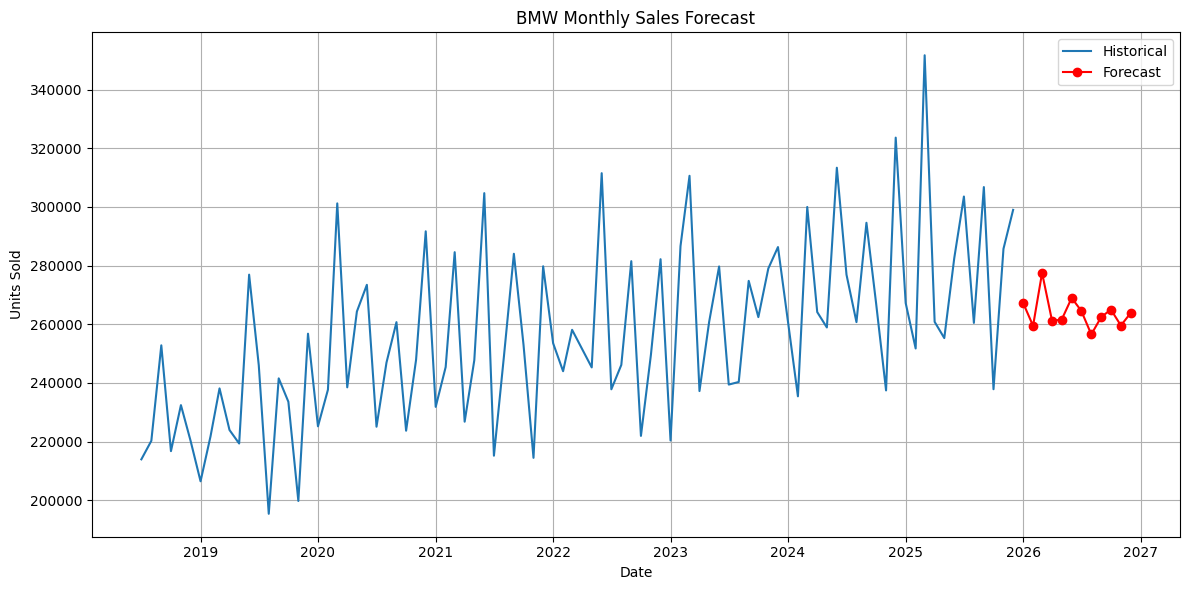

In [38]:
# forecasting total BMW sales for the next 12 months using recursive forecasting with lag features

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Load and aggregate data to monthly total sales
# ------------------------------------------------------------

df['Date'] = pd.to_datetime(df['Date'])

# Aggregate by month: sum Units_Sold, mean of other numeric features
monthly = df.groupby(df['Date'].dt.to_period('M')).agg({
    'Units_Sold': 'sum',
    'Avg_Price_EUR': 'mean',
    'BEV_Share': 'mean',
    'Premium_Share': 'mean',
    'GDP_Growth': 'mean',
    'Fuel_Price_Index': 'mean'
}).reset_index()
monthly['Date'] = monthly['Date'].dt.to_timestamp()
monthly = monthly.sort_values('Date').reset_index(drop=True)

print("Aggregated monthly data shape:", monthly.shape)
print(monthly.head())

# ------------------------------------------------------------
# 2. Create lag and rolling features on the aggregated series
# ------------------------------------------------------------
def create_features(df, target='Units_Sold'):
    df = df.copy()
    # Lags
    df['Sales_Lag_1'] = df[target].shift(1)
    df['Sales_Lag_3'] = df[target].shift(3)
    df['Sales_Lag_6'] = df[target].shift(6)
    # Rolling means
    df['Sales_Rolling_3'] = df[target].rolling(3).mean()
    df['Sales_Rolling_6'] = df[target].rolling(6).mean()
    # Growth rate (percentage change)
    df['Sales_Growth'] = df[target].pct_change()
    # Month and quarter
    df['Month'] = df['Date'].dt.month
    df['Quarter'] = df['Date'].dt.quarter
    # EV Demand Index (interaction)
    df['EV_Demand_Index'] = df['BEV_Share'] * df['Fuel_Price_Index']
    return df

monthly_features = create_features(monthly)

# Drop rows with NaN created by lag/rolling features
monthly_features = monthly_features.dropna().reset_index(drop=True)

print("Feature-engineered monthly data shape:", monthly_features.shape)

# ------------------------------------------------------------
# 3. Prepare train/test split (time‑based)
# ------------------------------------------------------------
# Use all but the last 12 months for training, last 12 for testing
train_size = len(monthly_features) - 12
train = monthly_features.iloc[:train_size]
test = monthly_features.iloc[train_size:]

# Define features (exclude target, date, and any non‑predictive)
exclude_cols = ['Date', 'Units_Sold']
feature_cols = [c for c in train.columns if c not in exclude_cols]

X_train = train[feature_cols]
y_train = train['Units_Sold']
X_test = test[feature_cols]
y_test = test['Units_Sold']

# Scale numerical features (optional)
scaler = StandardScaler()
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# ------------------------------------------------------------
# 4. Train XGBoost model (native API with early stopping)
# ------------------------------------------------------------
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    'objective': 'reg:squarederror',
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42
}

evals = [(dtrain, 'train'), (dtest, 'eval')]
model = xgb.train(
    params,
    dtrain,
    num_boost_round=300,
    evals=evals,
    early_stopping_rounds=20,
    verbose_eval=False
)

# Evaluate on test set
y_pred = model.predict(dtest)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"\nTest MAE : {mae:.2f}")
print(f"Test RMSE: {rmse:.2f}")

# ------------------------------------------------------------
# 5. Recursive forecast for the next 12 months
# ------------------------------------------------------------
# Prepare a dataframe with the last available row and future dates
last_date = monthly_features['Date'].iloc[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=12, freq='MS')
future_df = pd.DataFrame({'Date': future_dates})

# We'll need to carry forward the last known values for exogenous variables
# For simplicity, we assume they remain constant.
last_row = monthly_features.iloc[-1].copy()

forecast = []
current_features = monthly_features.copy()  # will extend with predictions

for i in range(12):
    # Create the next row with date and last‑known exogenous values
    next_date = future_dates[i]
    new_row = {
        'Date': next_date,
        'Avg_Price_EUR': last_row['Avg_Price_EUR'],
        'BEV_Share': last_row['BEV_Share'],
        'Premium_Share': last_row['Premium_Share'],
        'GDP_Growth': last_row['GDP_Growth'],
        'Fuel_Price_Index': last_row['Fuel_Price_Index'],
        'Month': next_date.month,
        'Quarter': next_date.quarter,
    }
    # Compute lags and rolling features using the current_features series
    # We need the most recent actual/predicted values for lags
    # Lags: we look at the last 6 values from current_features
    last_6 = current_features['Units_Sold'].iloc[-6:].tolist()
    # Pad with zeros if not enough history? But we have history.
    new_row['Sales_Lag_1'] = last_6[-1] if len(last_6) >= 1 else 0
    new_row['Sales_Lag_3'] = last_6[-3] if len(last_6) >= 3 else 0
    new_row['Sales_Lag_6'] = last_6[-6] if len(last_6) >= 6 else 0
    # Rolling averages
    new_row['Sales_Rolling_3'] = np.mean(last_6[-3:]) if len(last_6) >= 3 else np.nan
    new_row['Sales_Rolling_6'] = np.mean(last_6[-6:]) if len(last_6) >= 6 else np.nan
    # Growth rate: percentage change from previous value
    new_row['Sales_Growth'] = (last_6[-1] / last_6[-2] - 1) if len(last_6) >= 2 else 0
    # EV Demand Index
    new_row['EV_Demand_Index'] = new_row['BEV_Share'] * new_row['Fuel_Price_Index']

    # Create a DataFrame for this row
    row_df = pd.DataFrame([new_row])

    # Scale numerical features using the same scaler
    row_df[num_cols] = scaler.transform(row_df[num_cols])

    # Predict
    drow = xgb.DMatrix(row_df[feature_cols])
    pred = model.predict(drow)[0]
    forecast.append(pred)

    # Add the predicted value to current_features for next iteration
    new_row['Units_Sold'] = pred
    current_features = pd.concat([current_features, pd.DataFrame([new_row])], ignore_index=True)

# ------------------------------------------------------------
# 6. Display forecast
# ------------------------------------------------------------
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecasted_Units_Sold': forecast
})
print("\n12‑Month Sales Forecast:")
print(forecast_df)

# Optional: plot historical + forecast
plt.figure(figsize=(12, 6))
plt.plot(monthly_features['Date'], monthly_features['Units_Sold'], label='Historical')
plt.plot(forecast_df['Date'], forecast_df['Forecasted_Units_Sold'], 'ro-', label='Forecast')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.title('BMW Monthly Sales Forecast')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [39]:
import joblib
joblib.dump(model, 'bmw_sales_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(feature_cols, 'feature_cols.pkl')

['feature_cols.pkl']